In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# 信号抽出: 色付き雑音からの微弱信号回収

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_signal_extraction.ipynb)


このケーススタディは legacy の weak-signal notebook を公開 gallery 向けに整理したものです。物理的に見たいのは、生波形では見えない狭帯域信号をどうやって回収するかです。

ここでは弱い単色線を注入し、ASD で候補周波数を見つけ、band-pass で取り出してから簡単な正弦波モデルを当てます。

- **関連 API**: [Time Series API](../../reference/api/timeseries.rst), [Signal API](../../reference/api/signal.rst)
- **関連理論**: [検証済みアルゴリズム](../validated_algorithms.md), [数値安定性](../numerical_stability.md)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from gwexpy import TimeSeries

duration = 32
sample_rate = 4096
signal_freq = 123.4
signal_amp = 0.5
noise_std = 5.0
t = np.linspace(0, duration, int(duration * sample_rate), endpoint=False)

# The injected tone is far below the broadband noise floor, which is why it disappears in the raw waveform.
noise = np.random.normal(0, noise_std, size=len(t))
clean_signal = signal_amp * np.sin(2 * np.pi * signal_freq * t)
ts = TimeSeries(noise + clean_signal, t0=0, sample_rate=sample_rate, name="Noisy Data", unit="V")


## 1. 候補帯域を見つける

ASD の平均化は推定分散を減らすので、時間波形では見えない狭帯域線が統計的に見えるようになります。

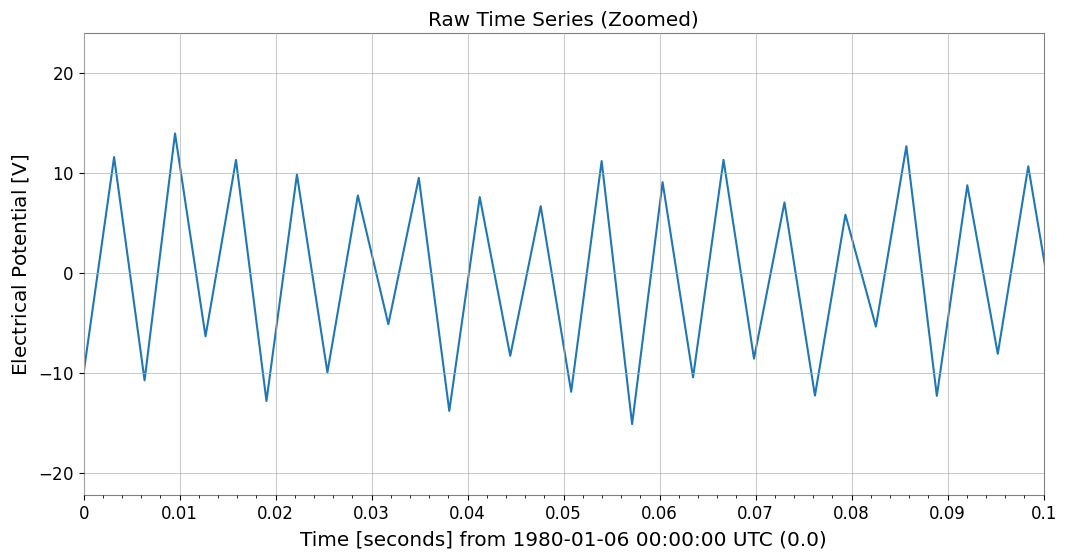

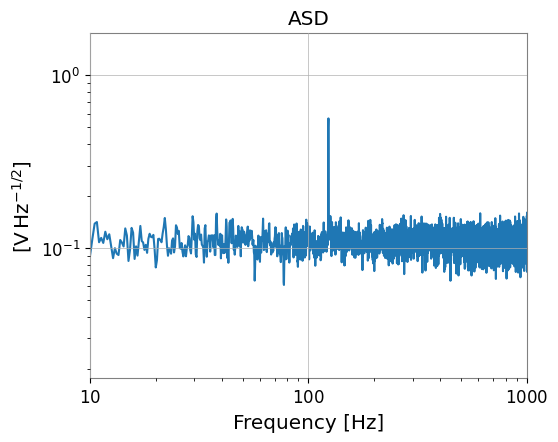

In [3]:
plot = ts.plot()
plot.gca().set_xlim(0, 0.1)
plot.gca().set_title("Raw Time Series (Zoomed)")
plt.show()

asd = ts.asd(fftlength=4, method="welch")
plot = asd.plot()
plot.gca().set_xlim(10, 1000)
plot.gca().set_yscale("log")
plot.gca().set_title("ASD")
plt.show()


## 2. フィルタしてフィットする

band-pass は注入線を残しつつ不要な広帯域成分を落とすためのものです。帯域を狭くしすぎると波形を歪め、広くしすぎると雑音を戻してしまいます。

- **関連 API**: [Time Series API](../../reference/api/timeseries.rst), [Fitting API](../../reference/api/fitting.rst)
- **関連理論**: [検証済みアルゴリズム](../validated_algorithms.md)

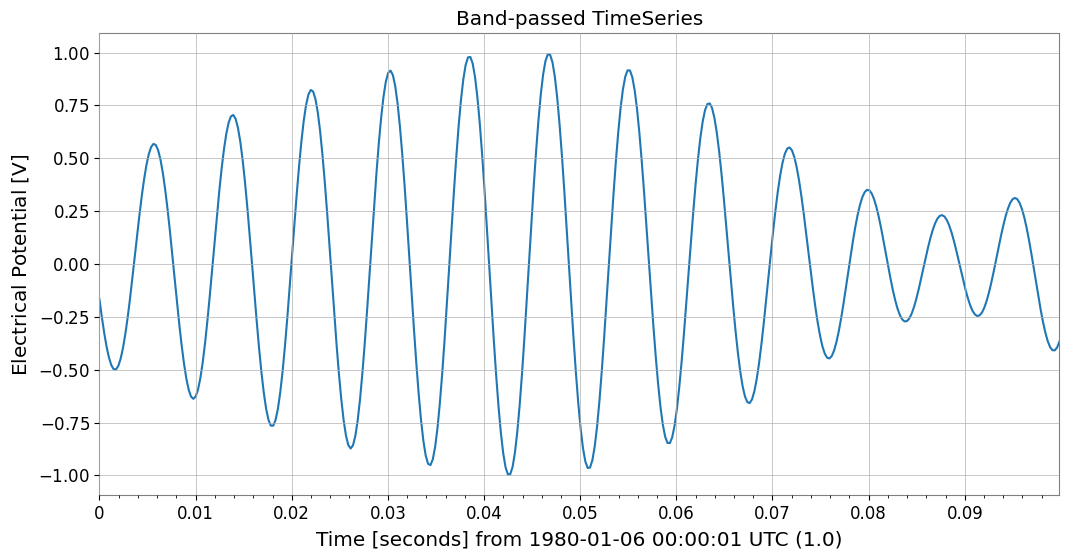

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.225e+04 (χ²/ndof = 203.6)│              Nfcn = 364              │
│ EDM = 2.07e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬────

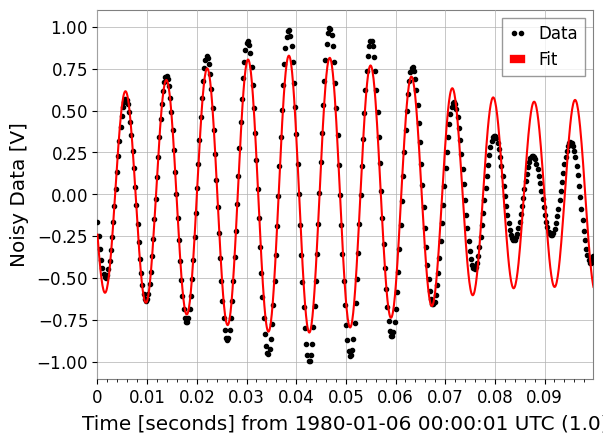

In [4]:
# Keep the band around the detected line so the fit sees the signal-dominated portion of the data.
filtered_ts = ts.bandpass(110, 130).crop(1, 1.1)

plot = filtered_ts.plot()
plot.gca().set_title("Band-passed TimeSeries")
plt.show()

def sine_model(t, amp, freq, phase, amp2, freq2, phase2):
    return amp * np.sin(2 * np.pi * freq * t + phase) * (1 + amp2 * np.sin(2 * np.pi * freq2 * t + phase2))

p0 = {"amp": 0.5, "freq": 123, "phase": 0, "amp2": 0.05, "freq2": 10, "phase2": 0}
limits = {"freq": (110, 130), "amp": (0.1, 5), "amp2": (0, 0.2), "freq2": (0, 50)}
result = filtered_ts.fit(sine_model, p0=p0, limits=limits, sigma=0.01)
print(result)
result.plot()
plt.show()
